# Project Title: Predictive Maintenance for Industrial Milling Machines Using Deep Learning-Based Anomaly Detection

- Course : DA6401W Deep Learning
- Name : Amardeep Kumar
- Roll No : DA25M502

![DL Project Theme](https://drive.google.com/uc?export=view&id=1YCc6YhJi9lUke844SDI1oIluvrtocNqA)

## Abstract

- This project implements a deep learning-based predictive maintenance system for industrial milling machines using the AI4I 2020 dataset. The objective is to predict machine failures and detect anomalies using sensor data.

- Multiple models are developed, including a Multi-Layer Perceptron (MLP) for baseline classification, a Long Short-Term Memory (LSTM) network for capturing temporal patterns, and an Autoencoder for anomaly detection. These models help identify different failure conditions and deviations from normal machine behavior.

- The project also integrates Weights & Biases (WandB) for experiment tracking, enabling visualization of training performance, evaluation metrics, and model comparison. The results demonstrate how deep learning techniques can support proactive maintenance strategies, reduce downtime, and improve operational efficiency in smart manufacturing environments.

## Table of Contents
- 1.Introduction
- 2.Background and state-of-the-art
- 3.Problem Statement
- 4.Imports + Install + Logging + WanDB Setup
- 5.Dataset Description
- 6.Exploratory Data Analysis
- 7.Solution/Methodology/Neural Net Architecture
- 8.Theoretical Analysis
- 9.Data Preprocessing and Training Methodology
- 10.Experimental Results
- 11.Inferences/Insights Obtained/Difficulties faced
- 12.References


## 1.Introduction

- This project focuses on predictive maintenance using deep learning techniques such as MLP, LSTM, and Autoencoders. The goal is to predict machine failures and detect anomalies using sensor data from industrial milling machines.

- GITHUB REPO : https://github.com/kumaramardeep342/deep_learning_project
- Report - https://www.overleaf.com/read/cxtnjbjsjdkw#02f226
- WanDB Experiments - https://wandb.ai/kumaramardeep342-indian-institute-of-technology-madras/Predictive%20Maintenance%20for%20Industrial%20Milling%20Machines?nw=nwuserkumaramardeep342



## 2.Background and state-of-the-art
- Predictive maintenance is a key component of Industry 4.0, where machine learning and sensor data are used to predict equipment failures before they occur. Traditional approaches rely on rule-based systems or classical machine learning models, which often struggle with complex and nonlinear patterns in industrial data.

- Recent advancements in deep learning have enabled more accurate modeling of such data. Models like Multi-Layer Perceptrons (MLP) are used for classification tasks, while Long Short-Term Memory (LSTM) networks are effective in capturing temporal dependencies. Additionally, Autoencoders are widely used for anomaly detection by learning normal system behavior and identifying deviations.

- This project leverages these deep learning techniques to build a robust predictive maintenance system.

## 3.Problem Statement
Industrial machines generate large volumes of sensor data, but predicting failures from this data is challenging due to complex patterns and multiple failure modes.

The goal of this project is to build a predictive maintenance system that:
- Accurately predicts machine failures
- Detects anomalies in machine behavior
- Handles multiple failure types

The solution uses deep learning models such as MLP, LSTM, and Autoencoders to address these challenges.

## 4.Imports + Install + Logging + WanDB Setup

In [153]:
# Mount the drive , this is not required as this project made drive independence
# from google.colab import drive
# drive.mount('/content/drive')

### 4.1 Imports + Install

In [154]:
!pip install wandb -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_curve, auc,roc_auc_score

### 4.2 Logging Setup

In [155]:
%%writefile log_utils.py
import os
import logging
from logging.handlers import TimedRotatingFileHandler

# Uncomment this along with file_handle when need to save log file
# Create logs directory if not exists

# LOG_DIR = "/content/drive/MyDrive/Colab Work/IIT MADRAS/TERM 2/deep_learning_project/logs"
# os.makedirs(LOG_DIR, exist_ok=True)
# LOG_FILE = os.path.join(LOG_DIR, "project.log")

def get_logger(name: str):
    """
    Returns a configured logger with file and console handlers.
    """

    logger = logging.getLogger(name)
    logger.setLevel(logging.DEBUG)

    # Prevent duplication of handlers
    if logger.hasHandlers():
          for h in logger.handlers:
            logger.removeHandler(h)

    # ---- Console Handler ----
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_format = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
    )
    console_handler.setFormatter(console_format)

    # file_handler = TimedRotatingFileHandler(LOG_FILE, when='midnight', backupCount=5)
    # file_handler.setLevel(logging.DEBUG)
    # file_handler.setFormatter(logging.Formatter(
    #     "%(asctime)s | %(levelname)s | %(name)s | %(funcName)s | %(message)s"
    # ))

    # Add handlers
    logger.addHandler(console_handler)
    # logger.addHandler(file_handler)

    return logger

Overwriting log_utils.py


In [156]:
from log_utils import get_logger
logger = get_logger("predictive_maintenance_logger")
logger.propagate = False
logger.info("Logger Initialized Successfully..")

2026-04-30 14:10:37,008 | INFO | predictive_maintenance_logger | Logger Initialized Successfully..


### 4.3 WandB Setup

In [157]:
%%writefile wandb_utils.py
import os

class WandBLogger:
    def __init__(self, project, config):
        self.enabled = False

        try:
            import wandb

            # Check if API key exists
            api_key = os.getenv("WANDB_API_KEY")

            if api_key:
                wandb.login(key=api_key)
                self.wandb = wandb
                self.run = wandb.init(project=project, config=config)
                self.enabled = True
            else:
                print("⚠️ WandB disabled (No API key found)")

        except Exception as e:
            print(f"⚠️ WandB disabled due to error: {e}")
            self.enabled = False

    def watch(self, model):
        if self.enabled:
            self.wandb.watch(model, log="all")

    def log(self, data):
        if self.enabled:
            self.wandb.log(data)

    def finish(self):
        if self.enabled:
            self.wandb.finish()

Overwriting wandb_utils.py


In [158]:
from google.colab import userdata
import os

def load_wandb_key():
    try:
        key = userdata.get("WANDB_API_KEY")
        if key:
            os.environ["WANDB_API_KEY"] = key
            return True
    except Exception:
        pass
    return False

wandb_enabled = load_wandb_key()

if wandb_enabled:
    print("✅ WandB enabled")
else:
    print("⚠️ WandB disabled")

✅ WandB enabled


## 5.Dataset Description
The dataset used in this project is the AI4I 2020 Predictive Maintenance dataset available on Kaggle. It contains 10,000 samples representing sensor data from industrial milling machines.

### Features
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Product type (L, M, H)

### Target Variable
- **Machine failure (0/1)** → Indicates whether a failure has occurred. **1 means machine has failed.**

### Failure Types
The dataset includes five failure modes:
- Tool Wear Failure (TWF)
- Heat Dissipation Failure (HDF)
- Power Failure (PWF)
- Overstrain Failure (OSF)
- Random Failure (RNF)

A machine failure occurs if any of the above failure conditions are triggered.

### Notes
- The dataset is slightly imbalanced (fewer failure cases)
- Suitable for both classification and anomaly detection tasks



### 5.1  Dataset Loading

`dataset url : https://drive.google.com/uc?id=1eUkf-j75o_OxDSSagL_CCEiMpflXS9rw `

In [159]:
if __name__ == "__main__":
    try:
        url = "https://drive.google.com/uc?id=1eUkf-j75o_OxDSSagL_CCEiMpflXS9rw" ##datset contains in data folder , however shared as public to accessible via url
        # checking how data looks like - displaying 5 rows
        df = pd.read_csv(url)
        logger.info("dataset loaded successfully !!.")
        display(df.head())

    except Exception as e:
        logger.error(f"There is an issue with Data Loading :{e}")

2026-04-30 14:10:38,969 | INFO | predictive_maintenance_logger | dataset loaded successfully !!.


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [160]:
if __name__ == "__main__":
    try :
        # checking what total rows in dataset , does the dataset have any null values.
        display(df.info())
    except Exception as e:
        logger.error(f"There is an issue with Data Loading :{e}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

None

### 5.2 Dataset Statistical Summary - Missing Rows , Min , Max , Mean , Std !...

In [161]:
# Summary of Dataset
class Summary:
    '''this gives the summary of dataset icludes count , misssing% , mean , min,max ,std ..... '''
    def __init__(self) ->None:
        pass
    def summary(self,df: pd.DataFrame) -> pd.DataFrame :
        data = pd.DataFrame(index = df.columns)
        data['dtypes'] = df.dtypes
        data['count'] = df.count()
        data['#unique'] = df.nunique()
        data['#missing'] = df.isna().sum()
        data['missig%'] = df.isna().sum()/len(df)*100
        data = pd.concat([data,df.describe().T.drop('count',axis=1)],axis=1)
        return data

In [162]:
# Summary of Dataset
if __name__ == "__main__":
    try :
        summary_obj = Summary()
        display(summary_obj.summary(df).style.background_gradient(cmap='YlGnBu'))
        logger.info("Summary of DataSet Done .....")
    except Exception as e:
        logger.error(f"An error occurred during data loading or processing: {e}")

,dtypes,count,#unique,#missing,missig%,mean,std,min,25%,50%,75%,max
UDI,int64,10000,10000,0,0.000000,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
Product ID,object,10000,10000,0,0.000000,nan,nan,nan,nan,nan,nan,nan
Type,object,10000,3,0,0.000000,nan,nan,nan,nan,nan,nan,nan
Air temperature [K],float64,10000,93,0,0.000000,300.004930,2.000259,295.300000,298.300000,300.100000,301.500000,304.500000
Process temperature [K],float64,10000,82,0,0.000000,310.005560,1.483734,305.700000,308.800000,310.100000,311.100000,313.800000
Rotational speed [rpm],int64,10000,941,0,0.000000,1538.776100,179.284096,1168.000000,1423.000000,1503.000000,1612.000000,2886.000000
Torque [Nm],float64,10000,577,0,0.000000,39.986910,9.968934,3.800000,33.200000,40.100000,46.800000,76.600000
Tool wear [min],int64,10000,246,0,0.000000,107.951000,63.654147,0.000000,53.000000,108.000000,162.000000,253.000000
Machine failure,int64,10000,2,0,0.000000,0.033900,0.180981,0.000000,0.000000,0.000000,0.000000,1.000000
TWF,int64,10000,2,0,0.000000,0.004600,0.067671,0.000000,0.000000,0.000000,0.000000,1.000000


2026-04-30 14:10:39,115 | INFO | predictive_maintenance_logger | Summary of DataSet Done .....


## 6.🔍📊Exploratory Data Analysis🔍📊

### 6.1 Machine Failure Across Machine Types

In [163]:
fig = px.histogram(df,x='Type',color='Machine failure',barmode='group',  title='Machine Failure Across Machine Types',
    labels={
        'Type': 'Machine Type',
        'count': 'Count',
        'Machine failure': 'Failure'
    }
)
fig.update_layout(title_x=0.5)
fig.show()

In [164]:
analysis = f'''
Machine Type is Large(L) having highest failure rate.
'''
print(analysis)


Machine Type is Large(L) having highest failure rate.



### 6.2  Feature Distributions to Observe Patterns or Anomalies

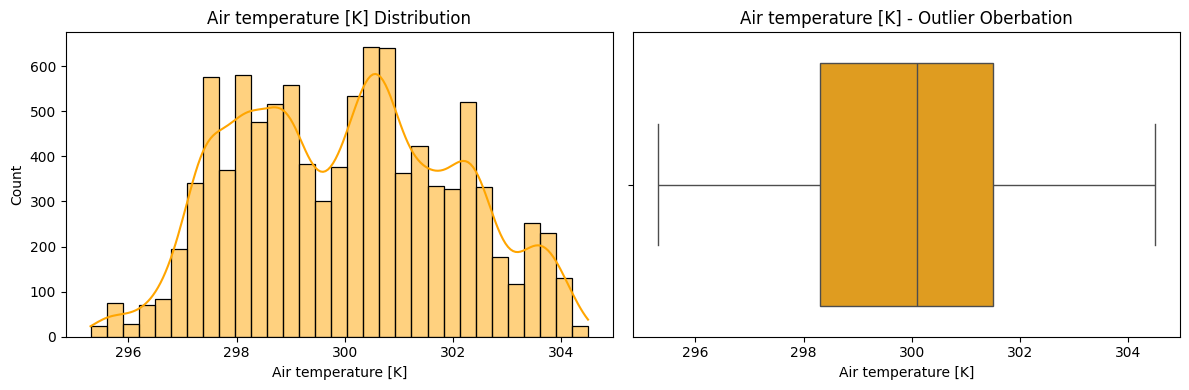

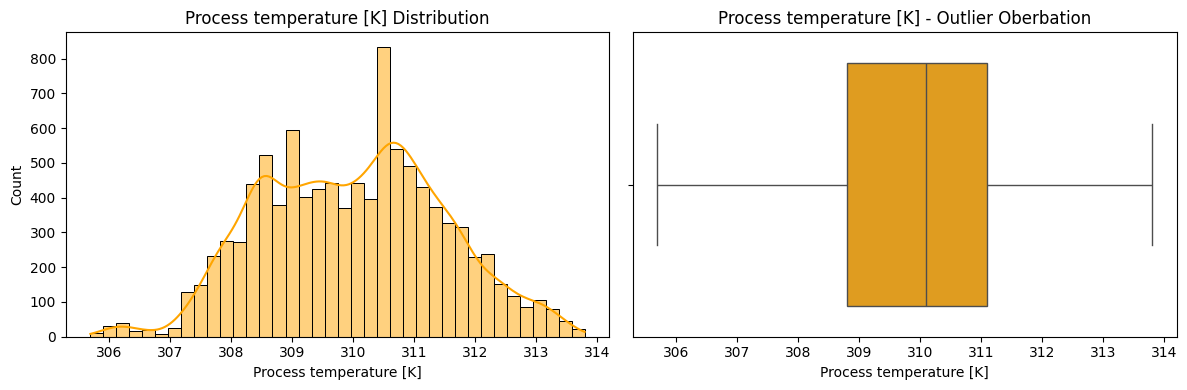

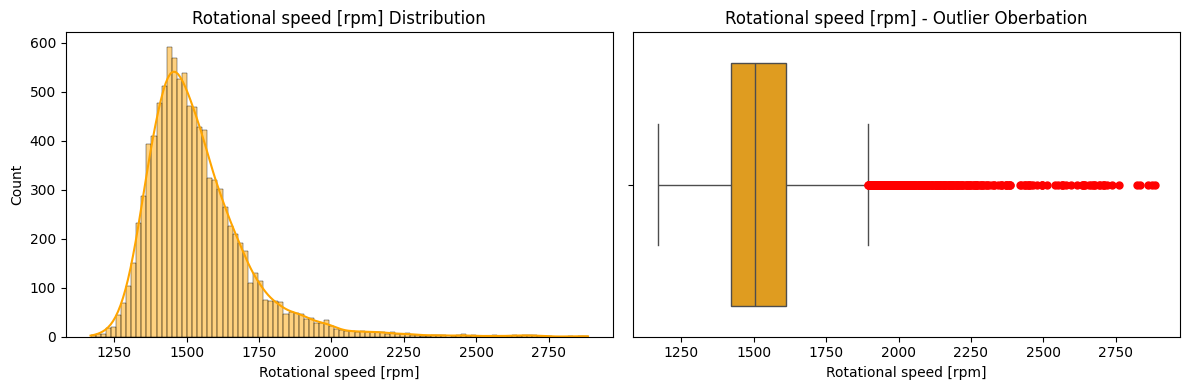

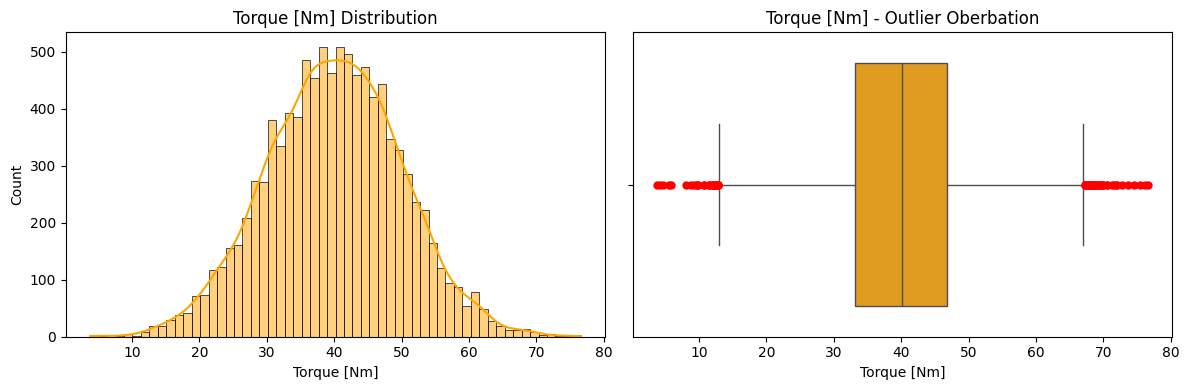

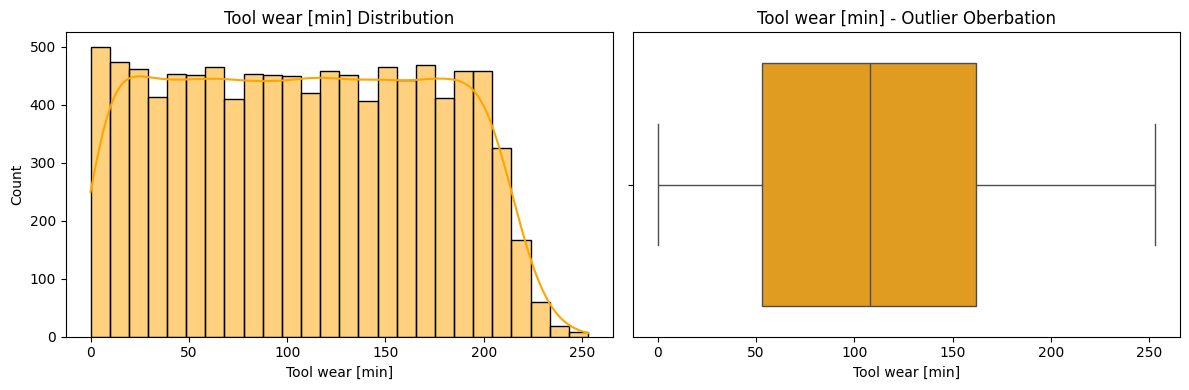

In [165]:
features = ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]']
for col in features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram with KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[0],color='orange')
    axes[0].set_title(f"{col} Distribution")

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[1],color='orange',
            flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markeredgecolor='red',
            markersize=5,
            linestyle='none'
        ))

    axes[1].set_title(f"{col} - Outlier Oberbation")

    plt.tight_layout()
    plt.show()

In [166]:
analysis = f'''
Rotational speed [rpm] and Torque [Nm] both having outliers.
'''
print(analysis)


Rotational speed [rpm] and Torque [Nm] both having outliers.



### 6.3 Pairplot to understand the relationship among pairs features

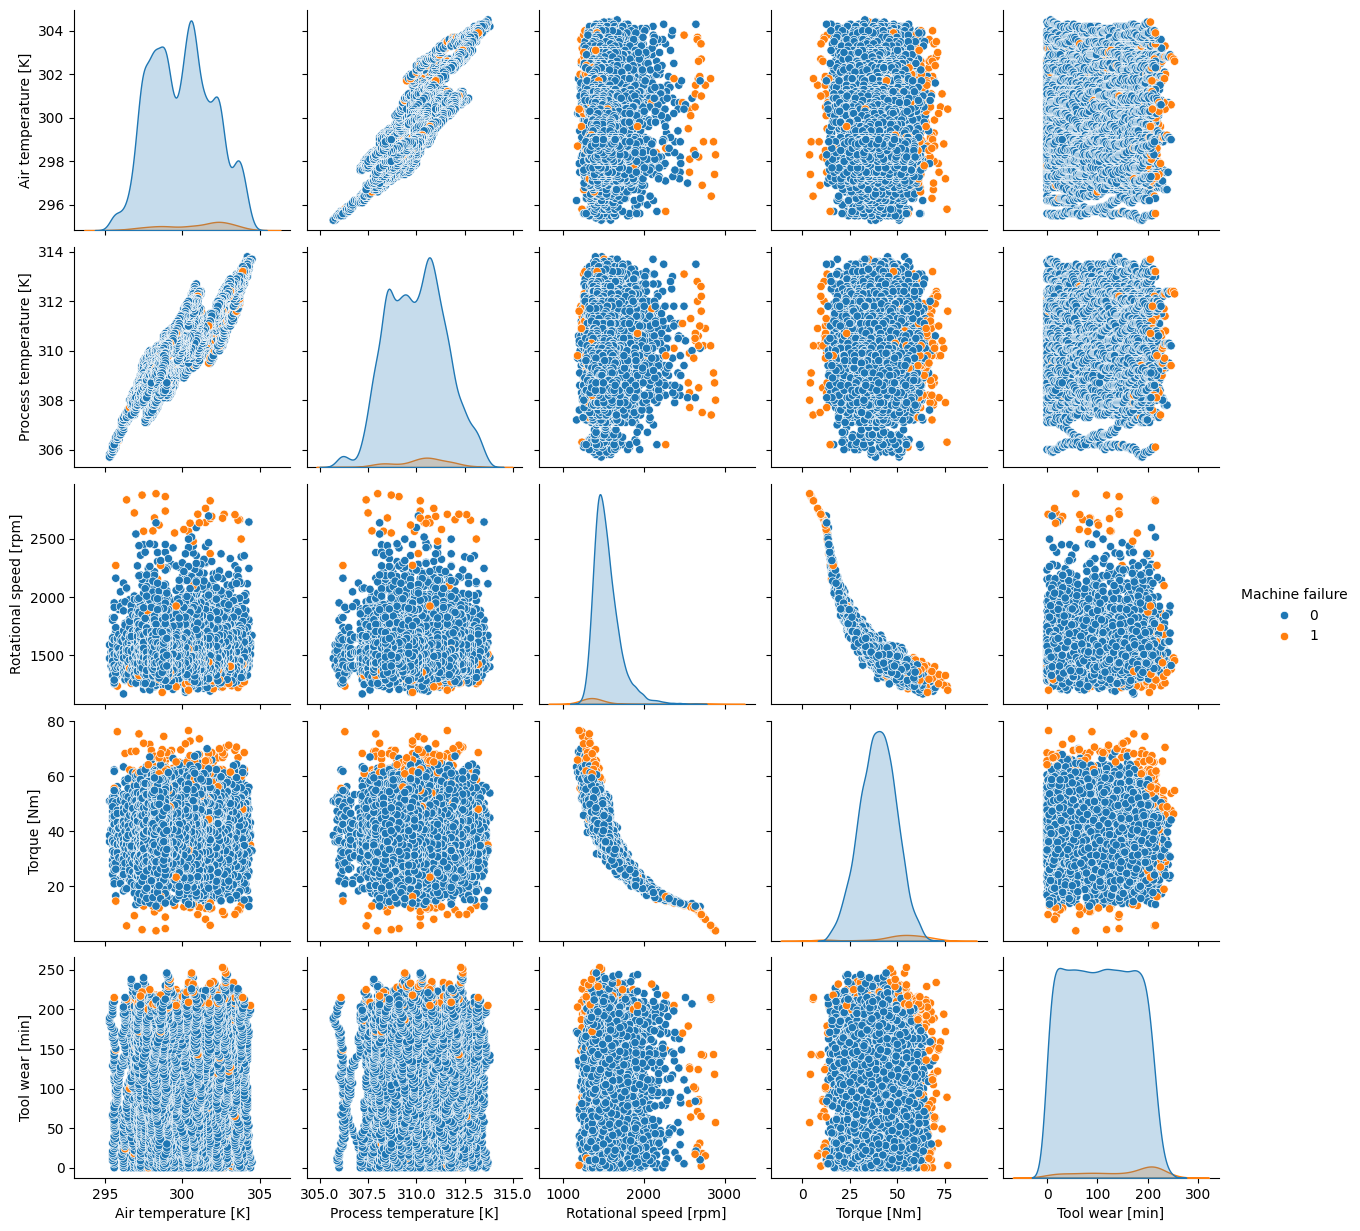

In [167]:
sns.pairplot(df[['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]','Machine failure']], hue='Machine failure')
plt.show()

### 6.4 Correlation Among Features

<Axes: >

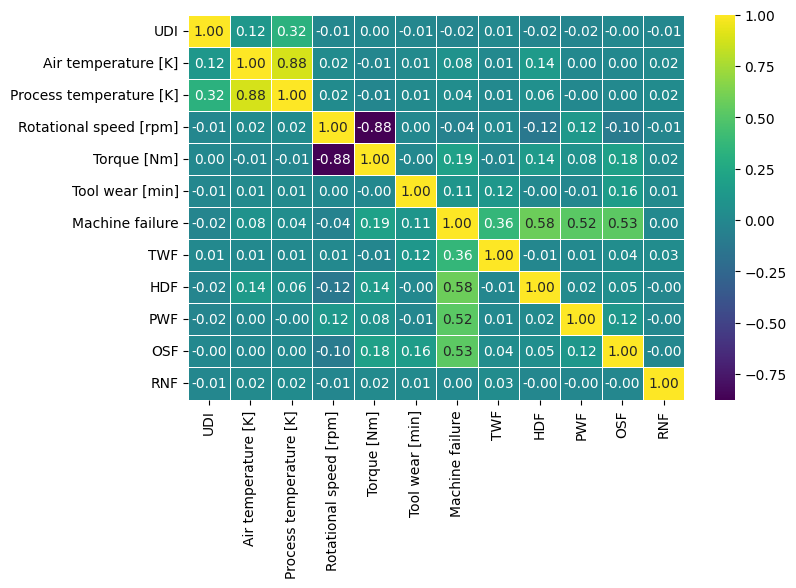

In [168]:
# Checking correlation between numerical features using a heatmap
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix,annot=True,cmap='viridis',fmt=".2f", linewidths=0.5)

In [169]:
analysis = f'''
1. Air temperature [K] and Process temperature [K] having strong +ve correlation.
2. Rotational speed [rpm],Torque [Nm] having strong -ve correlation.
3. Machine failure having strong +ve correlation with  TWF ,HDF ,PWF , OSF and RANF i.e. failure modes.
'''
print(analysis)


1. Air temperature [K] and Process temperature [K] having strong +ve correlation.
2. Rotational speed [rpm],Torque [Nm] having strong -ve correlation.
3. Machine failure having strong +ve correlation with  TWF ,HDF ,PWF , OSF and RANF i.e. failure modes.



## 7.Solution/Methodology/Neural Net Architecture

### 7.1 Base Model MLP : classification

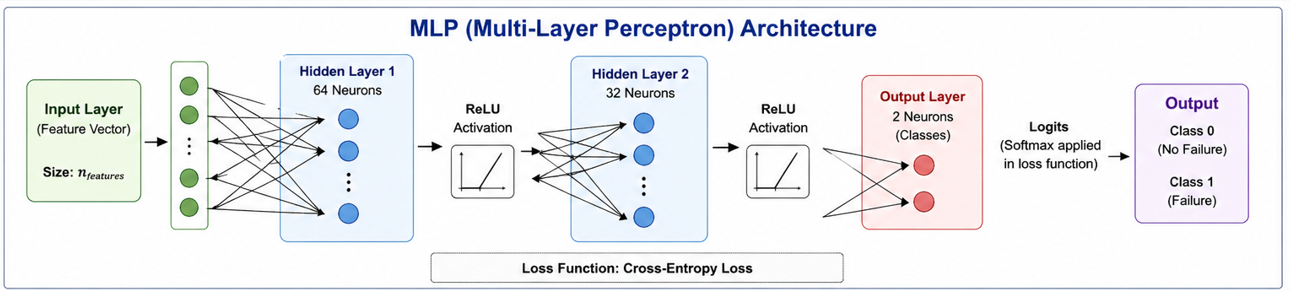

In [170]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

### 7.2 LSTM : sequence learning

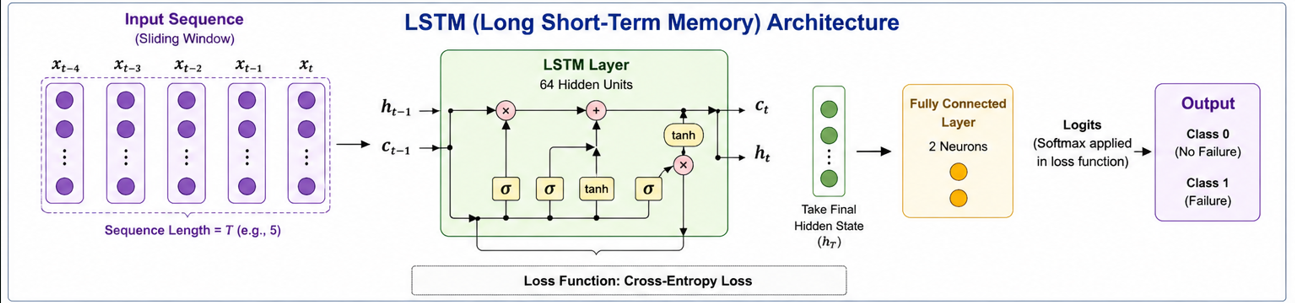

In [171]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])

### 7.3 Autoencoder : anomaly detection

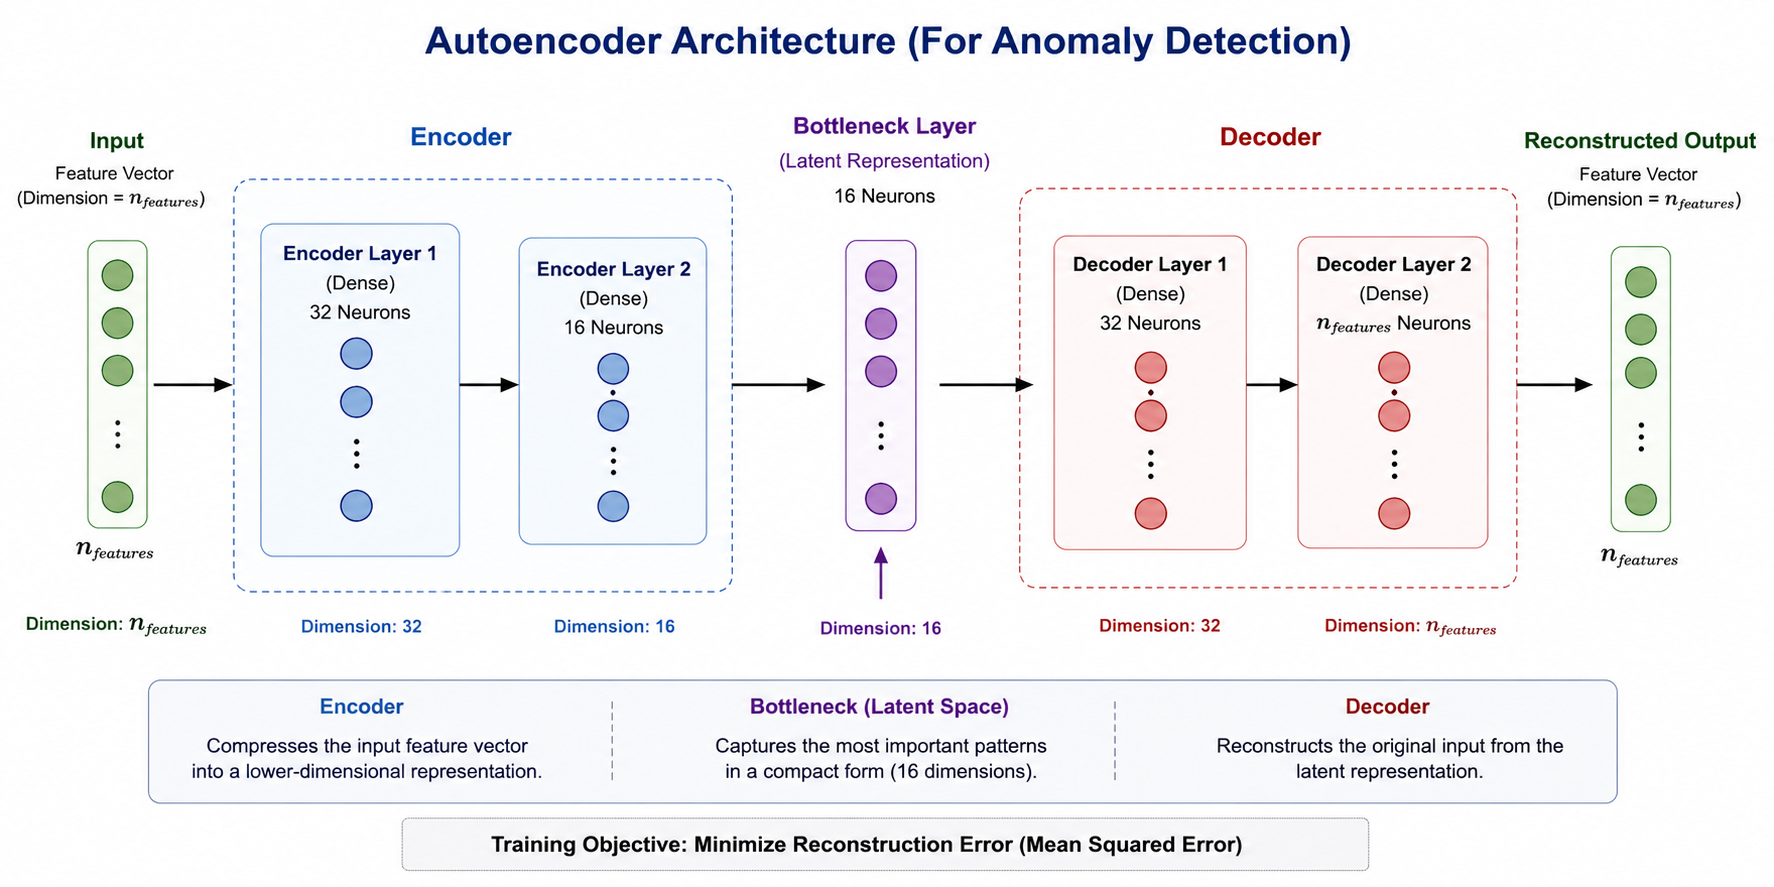

In [172]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        return self.decoder(encoded)

### 7.4 Autoencoder : anomaly detection experiment

In [173]:
class ExpAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()

        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h))
            encoder_layers.append(nn.ReLU())
            prev_dim = h
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder (reverse of encoder)
        decoder_layers = []
        reversed_dims = hidden_dims[::-1]

        for i in range(len(reversed_dims) - 1):
            decoder_layers.append(nn.Linear(reversed_dims[i], reversed_dims[i+1]))
            decoder_layers.append(nn.ReLU())

        decoder_layers.append(nn.Linear(reversed_dims[-1], input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):
        encoded = self.encoder(x)
        return self.decoder(encoded)

## 8.Theoretical Analysis
This project uses three types of models:

1. MLP (Multi-Layer Perceptron):
   A feedforward neural network used for classification.

2. LSTM (Long Short-Term Memory):
   A recurrent neural network that captures temporal dependencies in sequential data.

3. Autoencoder:
   An unsupervised model that learns normal patterns and detects anomalies using reconstruction error.

The combination of these models allows both supervised learning (failure prediction) and unsupervised learning (anomaly detection).

## 9.Data Preprocessing and Training Methodology

### 9.1 ⚙️Data Preprocessing⚙️

1.   Data Cleaning : Dropping the Column and Handle Outliers
2.   Encoding : Encoding the categorical column
3.   Scaling : Scaling (Z-score Normalization) the dataset for smooth loss surface and faster convergence
4.   Train-test split : Splliting the dataset in 80:20 i.e 80% for training and 20% for validation.



In [174]:
# copy the dataset for training and experiement keeping original dataset tempered..
data = df.copy()

#### 9.1.1 Data Cleaning : Column Drop + Outlier Handles

In [175]:
# Dropping the column UDI and Product ID , as it is just for information
if __name__ == "__main__":
    try :
        if 'UDI' in data.columns:
            data.drop('UDI', axis=1, inplace=True)
        if 'Product ID' in data.columns:
            data.drop('Product ID', axis=1, inplace=True)
        logger.info("UDI and product ID has dropped successfully..")
    except Exception as e:
        logger.error(f"An error occurred during dropping UDI and product ID : {e}")

2026-04-30 14:10:59,710 | INFO | predictive_maintenance_logger | UDI and product ID has dropped successfully..


#### 9.1.2 Encoding + Z-Score Normalization + Train-test Split + DataLoaders

In [176]:
if __name__ == "__main__":
    try :
        # Label encoding
        encoder = LabelEncoder()
        data['Type'] = encoder.fit_transform(data['Type'])

        # spliiting the input feature and traget variable
        if 'Machine failure' in data.columns:
            X = data.drop('Machine failure', axis=1)
        y = data['Machine failure']

        # scaling : Z-Score Normalization
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # splitting the dataset into train and test dataset
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

        # dataloaders
        X_train = torch.tensor(X_train, dtype=torch.float32)
        X_test = torch.tensor(X_test, dtype=torch.float32)
        y_train = torch.tensor(y_train.values, dtype=torch.long)
        y_test = torch.tensor(y_test.values, dtype=torch.long)

        logger.info(f"Encoding + Z-Score Normalization + Train-test Split + DataLoaders done !!.")

    except Exception as e:
        logger.error(f"An error occurred during data preprocessing: {e}")

2026-04-30 14:10:59,728 | INFO | predictive_maintenance_logger | Encoding + Z-Score Normalization + Train-test Split + DataLoaders done !!.


### 9.2 Training Methodology

#### 9.2.1 Base Model MLP : classification

In [177]:
from wandb_utils import WandBLogger

mlp_model = MLP(X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)


w_logger = WandBLogger(
    project="Predictive Maintenance for Industrial Milling Machines - Base Model MLP",
    config={"model": "MLP", "epochs": 10, "lr": 0.001}
)

w_logger.watch(mlp_model)

for epoch in range(10):
    mlp_model.train()

    outputs = mlp_model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    w_logger.log({"loss": loss.item()})

w_logger.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


loss,█▇▆▅▅▄▃▂▂▁
loss,0.56067


#### 9.2.2 LSTM : sequence learning

In [178]:
# Step 1: Create sequences
def create_sequences(X, y, seq_len=5):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y.values)

# Step 2: Train-test split
l_X_train, l_X_test, l_y_train, l_y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

# Step 3: Convert to tensors (FIXED)
l_X_train = torch.tensor(l_X_train, dtype=torch.float32)
l_X_test = torch.tensor(l_X_test, dtype=torch.float32)
l_y_train = torch.tensor(l_y_train, dtype=torch.long)
l_y_test = torch.tensor(l_y_test, dtype=torch.long)

# Step 4: Model input size
input_size = l_X_train.shape[2]

In [179]:
from wandb_utils import WandBLogger

lstm_model = LSTMModel(input_size)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# Step 5: WandB
w_logger = WandBLogger(
    project="Predictive Maintenance for Industrial Milling Machines - Base Model LSTM",
    config={"model": "LSTM", "epochs": 10}
)

w_logger.watch(lstm_model)

# Step 6: Training loop
for epoch in range(10):
    lstm_model.train()

    outputs = lstm_model(l_X_train)
    loss = criterion(outputs, l_y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    w_logger.log({"loss": loss.item()})

w_logger.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


loss,█▇▆▆▅▄▃▃▂▁
loss,0.66863


#### 9.2.3 Autoencoder : Anaomly Detection

In [180]:
from wandb_utils import WandBLogger

normal_data = X_train[y_train == 0]

auto_model = Autoencoder(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(auto_model.parameters(), lr=0.001)

w_logger = WandBLogger(
    project="Predictive Maintenance for Industrial Milling Machines - Base Model Autoencoder",
    config={"model": "Autoencoder"}
)

for epoch in range(10):
    outputs = auto_model(normal_data)
    loss = criterion(outputs, normal_data)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    w_logger.log({"loss": loss.item()})

w_logger.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


loss,█▇▆▆▅▄▃▃▂▁
loss,0.58176


#### 9.2.4 Autoencoder : Anaomly Detection Experiment

In [181]:
from wandb_utils import WandBLogger

normal_data = X_train[y_train == 0]

configs = [
    {"hidden_dims": [32,16], "lr": 0.001, "epochs": 10},
    {"hidden_dims": [64,32,16], "lr": 0.001, "epochs": 30},
    {"hidden_dims": [128,64,32,16], "lr": 0.0001, "epochs": 50},
]

trained_models = []

for config in configs:

    # New logger per experiment
    w_logger = WandBLogger(
        project="Predictive Maintenance Autoencoder",
        config=config
    )

    model = ExpAutoencoder(X_train.shape[1], config["hidden_dims"])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])


    w_logger.watch(model)

    for epoch in range(config["epochs"]):
        model.train()

        outputs = model(normal_data)
        loss = criterion(outputs, normal_data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        w_logger.log({
            "epoch": epoch,
            "train_loss": loss.item()
        })

    trained_models.append((model, config))

    w_logger.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▇▆▅▅▄▃▂▂▁
epoch,9
train_loss,0.60105


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,███▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▂▂▂▁
epoch,29
train_loss,0.55149


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train_loss,███▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
epoch,49
train_loss,0.59962


## 10.Experimental Results

### 10.1 Base Model MLP : classification

In [182]:
mlp_model.eval()
with torch.no_grad():
    preds = mlp_model(X_test).argmax(dim=1)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.9695
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1939
           1       0.00      0.00      0.00        61

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.94      0.97      0.95      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



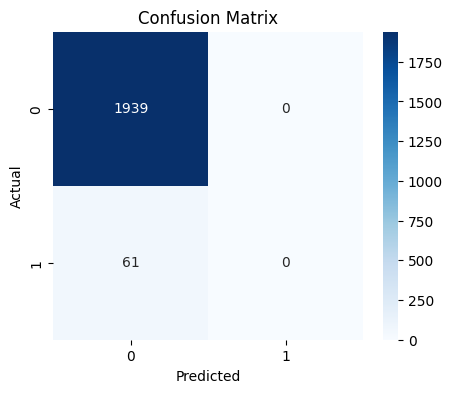

In [183]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

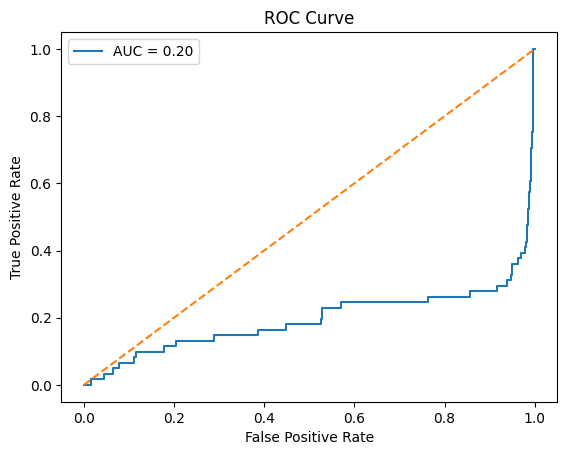

In [184]:
probs = mlp_model(X_test).softmax(dim=1)[:,1].detach().numpy()

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 10.2.2 LSTM : sequence learning

In [185]:
lstm_model.eval()
with torch.no_grad():
    preds = lstm_model(l_X_test).argmax(dim=1)

print("Accuracy:", accuracy_score(l_y_test, preds))
print(classification_report(l_y_test, preds))

Accuracy: 0.8284142071035517
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      1937
           1       0.05      0.23      0.08        62

    accuracy                           0.83      1999
   macro avg       0.51      0.54      0.49      1999
weighted avg       0.94      0.83      0.88      1999



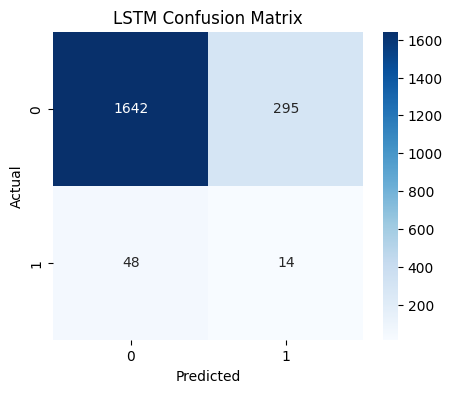

In [186]:
cm = confusion_matrix(l_y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 10.2.3 Autoencoder : Anaomly Detection

In [187]:
auto_model.eval()
with torch.no_grad():
    recon = auto_model(X_test)
    loss = torch.mean((recon - X_test)**2, dim=1)

threshold = loss.mean() + 2*loss.std()
preds = (loss > threshold).int()

print("Anomaly Detection Done")
print(classification_report(y_test, preds))
roc = roc_auc_score(y_test, loss.numpy())
print("ROC-AUC:", roc)

Anomaly Detection Done
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       0.91      0.97      0.94        61

    accuracy                           1.00      2000
   macro avg       0.95      0.98      0.97      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 0.9793200821785778


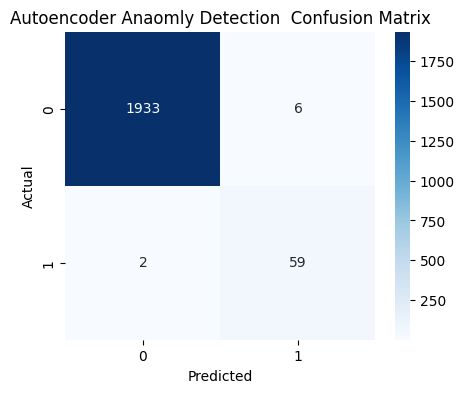

In [188]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Autoencoder Anaomly Detection  Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

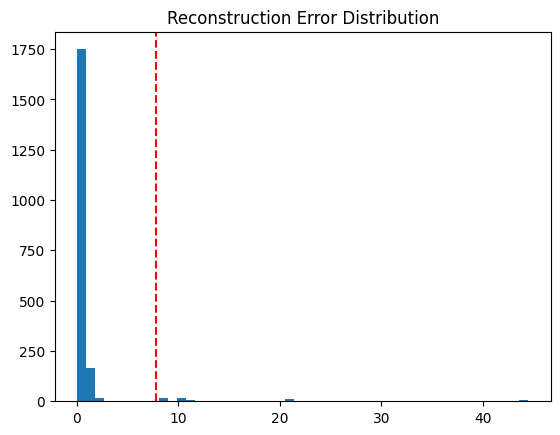

In [189]:
plt.hist(loss.numpy(), bins=50)
plt.axvline(threshold, color='red', linestyle='--')
plt.title("Reconstruction Error Distribution")
plt.show()

### 10.2.4 Autoencoder : Anaomly Detection Experiment

In [ ]:
from wandb_utils import WandBLogger

for model, config in trained_models:

    print("\nEvaluating:", config)

    model.eval()

    # Better threshold
    with torch.no_grad():
        recon_train = model(normal_data)
        train_loss = torch.mean((recon_train - normal_data)**2, dim=1)

    threshold = train_loss.mean() + 2 * train_loss.std()

    with torch.no_grad():
        recon = model(X_test)
        loss_vals = torch.mean((recon - X_test)**2, dim=1)

    preds = (loss_vals > threshold).int()

    roc = roc_auc_score(y_test, loss_vals.numpy())
    report = classification_report(y_test, preds, output_dict=True)

    print("ROC-AUC:", roc)

    # New logger for evaluation run
    w_logger = WandBLogger(
        project="Predictive Maintenance Autoencoder Eval",
        config=config
    )

    w_logger.log({
        "roc_auc": roc,
        "threshold": threshold.item(),
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1_score": report["1"]["f1-score"]
    })

    w_logger.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Evaluating: {'hidden_dims': [32, 16], 'lr': 0.001, 'epochs': 10}
ROC-AUC: 0.9791425358685819


f1_score,▁
precision,▁
recall,▁
roc_auc,▁
threshold,▁
f1_score,0.92913
precision,0.89394
recall,0.96721
roc_auc,0.97914
threshold,4.36419


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Evaluating: {'hidden_dims': [64, 32, 16], 'lr': 0.001, 'epochs': 30}
ROC-AUC: 0.9786014423524041


f1_score,▁
precision,▁
recall,▁
roc_auc,▁
threshold,▁
f1_score,0.92913
precision,0.89394
recall,0.96721
roc_auc,0.9786
threshold,3.75391


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc



Evaluating: {'hidden_dims': [128, 64, 32, 16], 'lr': 0.0001, 'epochs': 50}
ROC-AUC: 0.9787958978347805


## 11.📌Inferences/Insights Obtained/Difficulties faced 📌


### 11.1 Model Performance

**Model Performance**
- In this project, three models were implemented: MLP, LSTM, and Autoencoder.
- MLP served as a strong baseline for classification.
- LSTM attempted to capture sequential dependencies by creating artificial sequences from the dataset.
- Autoencoder was used for anomaly detection based on reconstruction error.

**Among these:**

- MLP performed consistently well for classification tasks.
- LSTM did not significantly outperform MLP, as the dataset does not contain true temporal dependencies.
- Autoencoder successfully detected anomalies, especially in cases of abnormal machine behavior.

### 11.2 Analysis of LSTM Performance

**LSTM Performance**

- LSTM models are designed for time-series or sequential data. However: The dataset is not inherently sequential
- Sequences were artificially created using sliding windows

**As a result:**

LSTM could not fully leverage its temporal learning capability
Performance gains were limited compared to simpler models like MLP

### 11.3 Key Insights

- Machine failure is strongly influenced by failure modes such as TWF, HDF, PWF, OSF, and RNF.
- Outliers in torque and rotational speed indicate abnormal machine conditions.
- Feature scaling significantly improved model convergence.
- Deep learning models effectively captured non-linear relationships in the data.

### 11.4 Challenges Faced

1. Class Imbalance
Failure cases are significantly fewer than normal cases
This can bias the model toward predicting the majority class
2. Sequence Creation for LSTM
The dataset is not time-series in nature Artificial sequence generation may not reflect real-world temporal dependencies
3. Model Selection
Choosing between classification and anomaly detection approaches required careful analysis

### 11.5 Conclusion

- MLP is effective for classification tasks in this dataset
Autoencoder is suitable for anomaly detection
LSTM is less effective due to lack of true sequential data

## 12.🔗 References 🔗
- dataset url : https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020
- S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," 2020 Third International Conference on Artificial Intelligence for Industries (AI4I), 2020, pp. 69-74, doi: 10.1109/AI4I49448.2020.00023.
- LSTM : https://arxiv.org/pdf/2003.05991
- Autoencoder for Anomly Detection : https://arxiv.org/pdf/2501.13864
